# Task 4 – Portfolio Optimization

## Objective

Use the forecasted Tesla returns together with historical returns of SPY and BND to construct an optimal portfolio using Modern Portfolio Theory (MPT).

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from pypfopt import plotting

from src.data_loader import load_processed_data

from src.portfolio import (
    calculate_historical_returns,
    calculate_expected_returns,
    covariance_matrix,
    optimize_max_sharpe,
    optimize_min_volatility,
)

In [4]:
tsla = load_processed_data("TSLA_processed.csv")

spy = load_processed_data("SPY_processed.csv")

bnd = load_processed_data("BND_processed.csv")

forecast = pd.read_csv(
    "../data/processed/tsla_future_forecast.csv",
    parse_dates=["Date"]
)

In [5]:
prices = pd.DataFrame({

    "TSLA": tsla["Adj Close"],

    "SPY": spy["Adj Close"],

    "BND": bnd["Adj Close"]

})

prices.head()

,TSLA,SPY,BND
Date,,,
2015-01-02,14.620667,169.687851,59.205658
2015-01-05,14.006000,166.623306,59.377548
2015-01-06,14.085333,165.053894,59.549507
2015-01-07,14.063333,167.110657,59.585297
2015-01-08,14.041333,170.076065,59.492184


In [6]:
returns = prices.pct_change().dropna()

returns.head()

,TSLA,SPY,BND
Date,,,
2015-01-05,-0.042041,-0.018060,0.002903
2015-01-06,0.005664,-0.009419,0.002896
2015-01-07,-0.001562,0.012461,0.000601
2015-01-08,-0.001564,0.017745,-0.001563
2015-01-09,-0.018802,-0.008013,0.001686


In [8]:
expected_returns = calculate_expected_returns(
    forecast["Forecast"],
    returns
)

expected_returns

TSLA   -0.25016
SPY     0.14432
BND     0.02025
dtype: float64

In [10]:
tsla = load_processed_data("TSLA_processed.csv")

spy = load_processed_data("SPY_processed.csv")

bnd = load_processed_data("BND_processed.csv")

forecast = pd.read_csv(
    "../data/processed/tsla_future_forecast.csv",
    parse_dates=["Date"]
)

In [11]:
prices = pd.DataFrame({
    "TSLA": tsla["Adj Close"],
    "SPY": spy["Adj Close"],
    "BND": bnd["Adj Close"]
})

prices.head()

,TSLA,SPY,BND
Date,,,
2015-01-02,14.620667,169.687851,59.205658
2015-01-05,14.006000,166.623306,59.377548
2015-01-06,14.085333,165.053894,59.549507
2015-01-07,14.063333,167.110657,59.585297
2015-01-08,14.041333,170.076065,59.492184


In [13]:
returns = calculate_historical_returns(prices)

returns.head()

,TSLA,SPY,BND
Date,,,
2015-01-05,-0.042041,-0.018060,0.002903
2015-01-06,0.005664,-0.009419,0.002896
2015-01-07,-0.001562,0.012461,0.000601
2015-01-08,-0.001564,0.017745,-0.001563
2015-01-09,-0.018802,-0.008013,0.001686


In [12]:
expected_returns = calculate_expected_returns(
    forecast["Forecast"],
    returns
)

expected_returns

TSLA   -0.25016
SPY     0.14432
BND     0.02025
dtype: float64

In [14]:
cov_matrix = covariance_matrix(returns)

cov_matrix

,TSLA,SPY,BND
TSLA,0.326926,0.049820,0.001790
SPY,0.049820,0.031169,0.001086
BND,0.001790,0.001086,0.002822


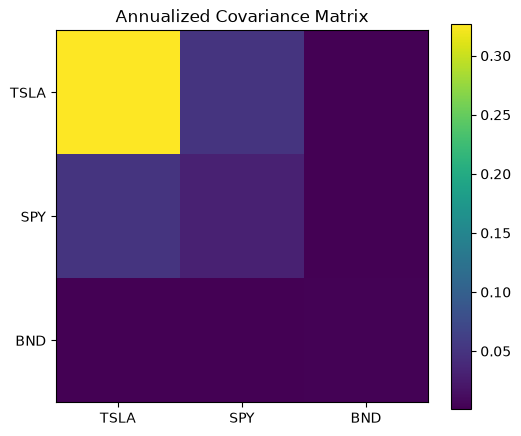

In [15]:
plt.figure(figsize=(6,5))

plt.imshow(cov_matrix)

plt.colorbar()

plt.xticks(
    range(3),
    cov_matrix.columns
)

plt.yticks(
    range(3),
    cov_matrix.columns
)

plt.title("Annualized Covariance Matrix")

plt.show()

In [16]:
weights_sharpe, performance_sharpe = optimize_max_sharpe(
    expected_returns,
    cov_matrix
)

weights_sharpe

OrderedDict([('TSLA', 0.0), ('SPY', 0.44815), ('BND', 0.55185)])

In [17]:
weights_min, performance_min = optimize_min_volatility(
    expected_returns,
    cov_matrix
)

weights_min

OrderedDict([('TSLA', 0.0), ('SPY', 0.05456), ('BND', 0.94544)])

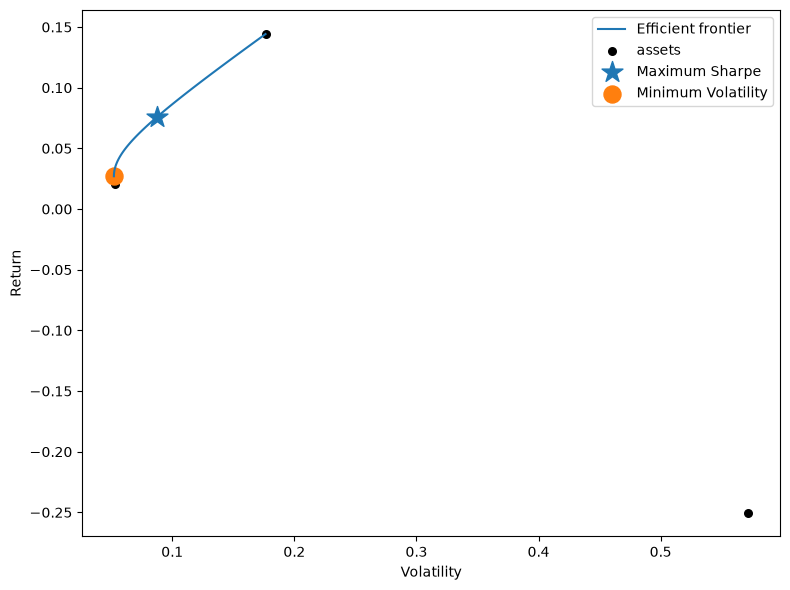

In [18]:
from pypfopt import EfficientFrontier

ef = EfficientFrontier(
    expected_returns,
    cov_matrix
)

fig, ax = plt.subplots(figsize=(8,6))

plotting.plot_efficient_frontier(
    ef,
    ax=ax,
    show_assets=True
)

ax.scatter(
    performance_sharpe[1],
    performance_sharpe[0],
    marker="*",
    s=250,
    label="Maximum Sharpe"
)

ax.scatter(
    performance_min[1],
    performance_min[0],
    marker="o",
    s=150,
    label="Minimum Volatility"
)

plt.legend()

plt.show()

In [19]:
portfolio_summary = pd.DataFrame({
    "Weight": weights_sharpe
})

portfolio_summary

,Weight
TSLA,0.00000
SPY,0.44815
BND,0.55185


In [20]:
performance = pd.DataFrame({

    "Metric":[
        "Expected Return",
        "Volatility",
        "Sharpe Ratio"
    ],

    "Value":performance_sharpe

})

performance

,Metric,Value
0,Expected Return,0.075853
1,Volatility,0.087502
2,Sharpe Ratio,0.866869


## Portfolio Recommendation

The Maximum Sharpe Ratio portfolio is recommended because it provides the highest expected return relative to portfolio risk.

The optimized allocation balances Tesla's higher forecasted growth potential with the diversification benefits of SPY and the stability provided by BND. Although Tesla contributes additional volatility, the combination of assets improves the overall risk-adjusted performance of the portfolio.

This allocation is appropriate for investors seeking long-term capital appreciation while maintaining diversification across equity and fixed-income markets.